<a href="https://colab.research.google.com/github/lianemm/fomc-citations/blob/main/deal_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload() # upload citations xlsx

Saving combined_citations.xlsx to combined_citations (1).xlsx


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages("citation_eda_plots.pdf")


def df_to_pdf_page(df, pdf, title=None, max_rows=30):
    """Render a DataFrame as a table and save it as one PDF page."""
    df_display = df.head(max_rows)  # avoid unreadably long tables
    fig_height = 0.4 * len(df_display) + 1.2  # scale height to row count
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=14, pad=20)

    tbl = ax.table(
        cellText=df_display.round(2).astype(str).values,
        colLabels=df_display.columns,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)
    tbl.auto_set_column_width(col=list(range(len(df_display.columns))))

    pdf.savefig()
    plt.show()
    if len(df) > max_rows:
        print(f"Note: table truncated to first {max_rows} of {len(df)} rows in PDF")


In [3]:
df = pd.read_excel("combined_citations.xlsx")

In [4]:
df = df.sort_values(["Year", "Meeting_Number", "Date"]).reset_index(drop=True)
df["Meeting_Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d")

In [5]:
meeting_order = (
    df[["Year", "Meeting_Number"]]
    .drop_duplicates()
    .sort_values(["Year", "Meeting_Number"])
    .reset_index(drop=True)
)
meeting_order["Global_Meeting_Index"] = meeting_order.index + 1
df = df.merge(meeting_order, on=["Year", "Meeting_Number"], how="left")

print(df.shape)
df.head()

(5870, 17)


,Date,Year,Month,Month_Name,Tealbook,Meeting_Number,Citation,Context,Section,Page,Printed_Page,Source_Type,Paper_Type,Pub_Name,Source_File,Meeting_Date,Global_Meeting_Index
0,20020507,2002,5,May,B,1,"Board Staff, ""The Behavior of Financial Market...",upward revision to the output gap and a method...,NaN,20,NaN,Fed Research,Staff Memo / Note,NaN,2002.xlsx,2002-05-07,1
1,20030625,2003,6,June,B,1,"Douglas Elmendorf, Dave Reifschneider, and Dav...",10 4 For an analysis of disinflation and defla...,"June 13, 2003.",17,NaN,Fed Research,Staff Memo / Note,NaN,2003.xlsx,2003-06-25,2
2,20031028,2003,10,October,B,2,"Vincent Reinhart, ""Committee Discussion of the...",9 9 “ Committee Discussion of the Wording of t...,NaN,16,NaN,Fed Research,Staff Memo / Note,NaN,2003.xlsx,2003-10-28,3
3,20040128,2004,1,January,A,1,Andrew (1992),moving average of past payouts); this change s...,Appendix,42,NaN,Unknown,Unknown,NaN,2004.xlsx,2004-01-28,4
4,20040810,2004,8,August,B,2,"Vincent Reinhart, ""A Potential Change in the W...",11 5 See “ A Potential Change in the Wording o...,NaN,21,NaN,Fed Research,Staff Memo / Note,NaN,2004.xlsx,2004-08-10,5


In [6]:
print(df["Source_Type"].value_counts())
print()
print(df["Tealbook"].value_counts())

Source_Type
Academic                                   4777
Unknown                                     701
Fed Research                                356
Government / International Organization      34
Private Sector / Market                       2
Name: count, dtype: int64

Tealbook
B    3015
A    2855
Name: count, dtype: int64


In [7]:
df["Is_Academic"] = df["Source_Type"] == "Academic"

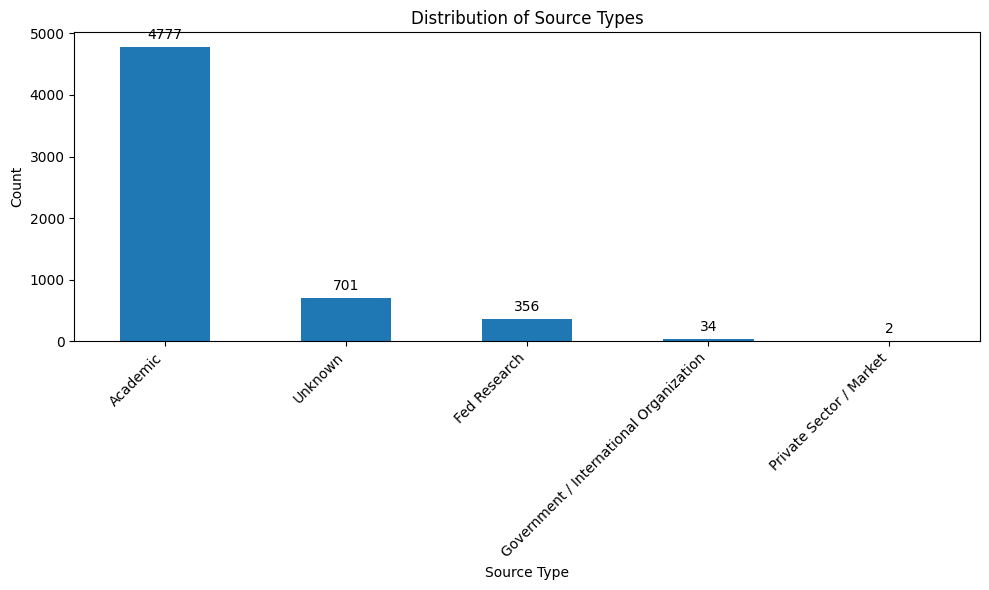

In [8]:
source_type_counts = df["Source_Type"].value_counts()

plt.figure(figsize=(10, 6))
ax = source_type_counts.plot(kind="bar")
plt.title("Distribution of Source Types")
plt.xlabel("Source Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
pdf.savefig()
plt.show()

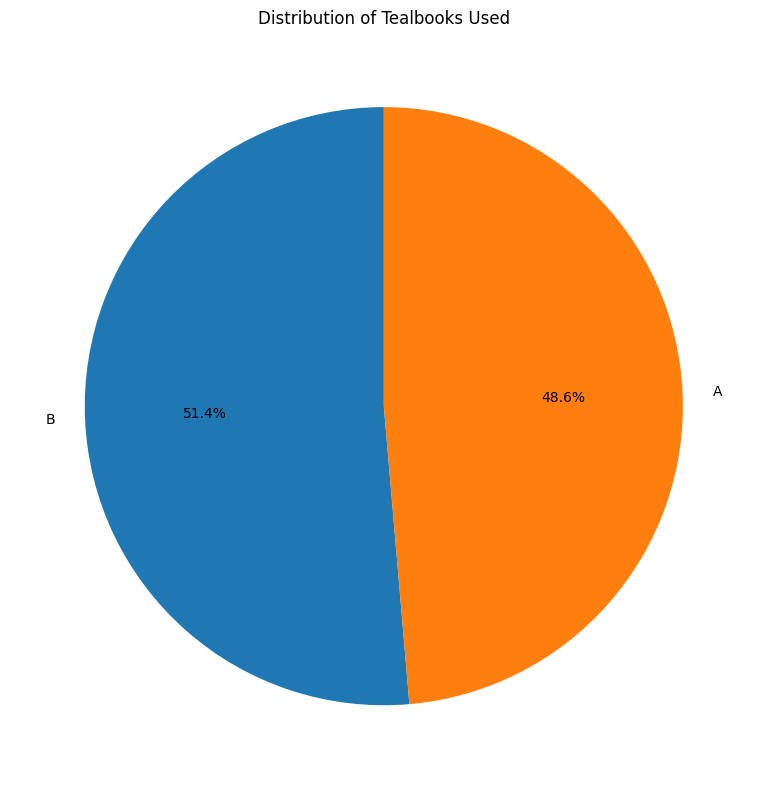

In [9]:
tealbook_counts = df["Tealbook"].value_counts()

plt.figure(figsize=(8, 8))
ax = tealbook_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Tealbooks Used")
ax.set_ylabel('')
plt.tight_layout()
pdf.savefig()
plt.show()

    Year  Total_Citations  Academic_Citations  Pct_Academic
0   2002                1                   0           0.0
1   2003                2                   0           0.0
2   2004                2                   0           0.0
3   2006               59                  56          94.9
4   2007              128                 116          90.6
5   2008              107                 102          95.3
6   2009              118                  94          79.7
7   2010               96                  84          87.5
8   2011              116                 103          88.8
9   2012              409                 362          88.5
10  2013              548                 497          90.7
11  2014              558                 508          91.0
12  2015              522                 461          88.3
13  2016              649                 552          85.1
14  2017              609                 500          82.1
15  2018              632               

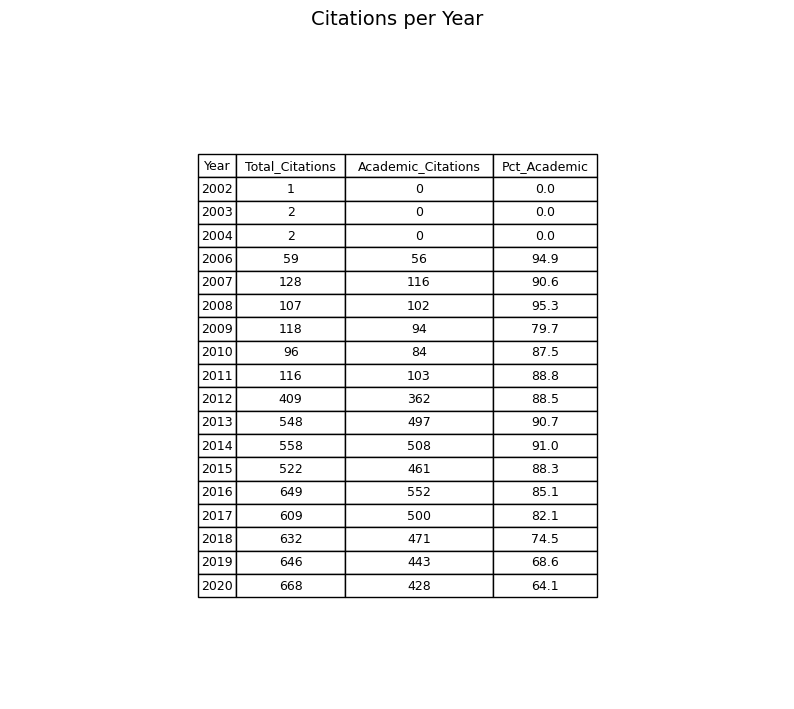

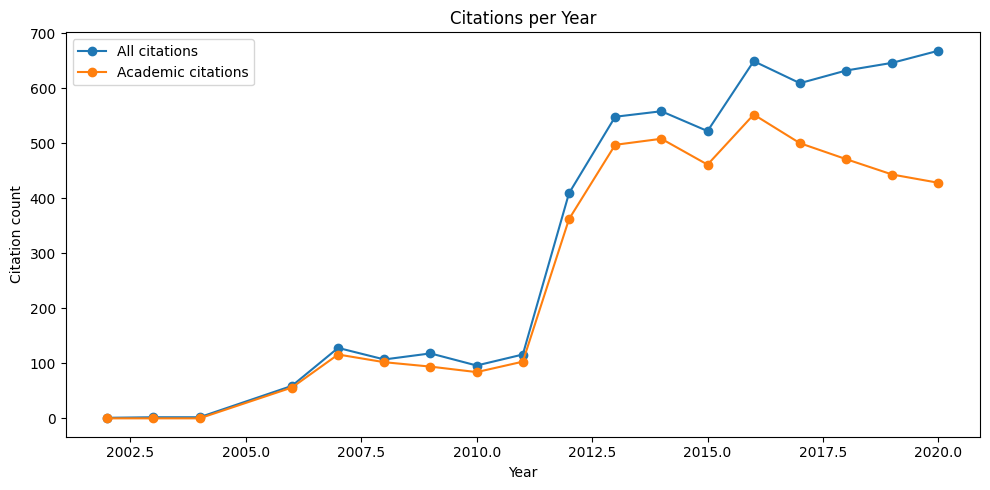

In [10]:
by_year = (
    df.groupby("Year")
    .agg(Total_Citations=("Citation", "size"), Academic_Citations=("Is_Academic", "sum"))
    .reset_index()
)
by_year["Pct_Academic"] = (by_year["Academic_Citations"] / by_year["Total_Citations"] * 100).round(1)
print(by_year)
df_to_pdf_page(by_year, pdf, title="Citations per Year")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_year["Year"], by_year["Total_Citations"], marker="o", label="All citations")
ax.plot(by_year["Year"], by_year["Academic_Citations"], marker="o", label="Academic citations")
ax.set_xlabel("Year")
ax.set_ylabel("Citation count")
ax.set_title("Citations per Year")
ax.legend()
plt.tight_layout()
pdf.savefig()
plt.show()

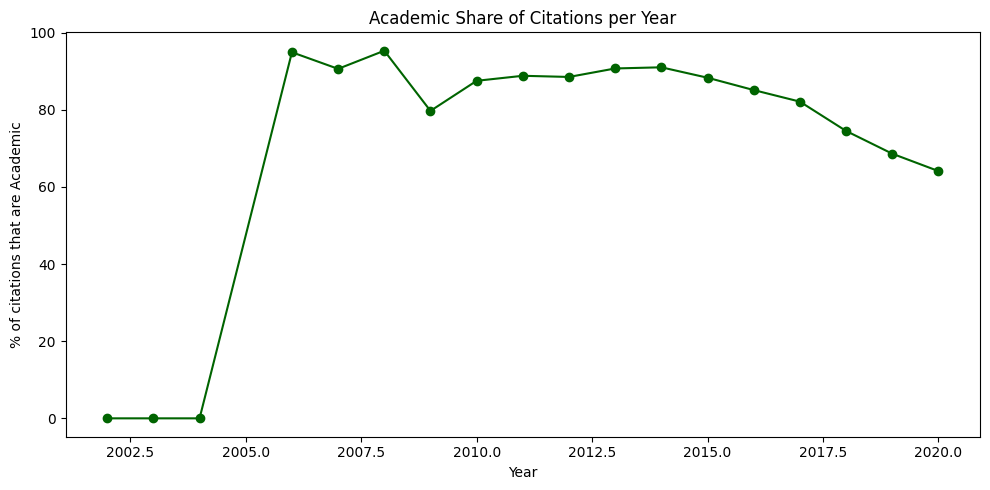

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_year["Year"], by_year["Pct_Academic"], marker="o", color="darkgreen")
ax.set_xlabel("Year")
ax.set_ylabel("% of citations that are Academic")
ax.set_title("Academic Share of Citations per Year")
plt.tight_layout()
pdf.savefig()
plt.show()

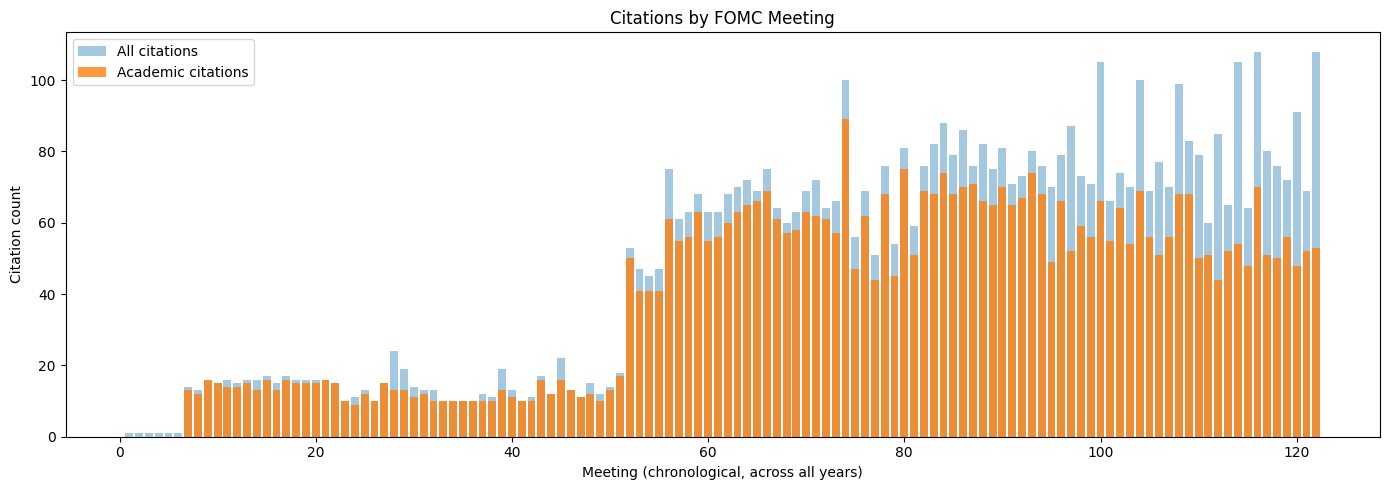

In [12]:
by_meeting = (
    df.groupby(["Global_Meeting_Index", "Year", "Meeting_Number"])
    .agg(Total_Citations=("Citation", "size"), Academic_Citations=("Is_Academic", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(by_meeting["Global_Meeting_Index"], by_meeting["Total_Citations"], label="All citations", alpha=0.4)
ax.bar(by_meeting["Global_Meeting_Index"], by_meeting["Academic_Citations"], label="Academic citations", alpha=0.8)
ax.set_xlabel("Meeting (chronological, across all years)")
ax.set_ylabel("Citation count")
ax.set_title("Citations by FOMC Meeting")
ax.legend()
plt.tight_layout()
pdf.savefig()
plt.show()

First year with all 8 meeting numbers present: 2007
Years included in truncated analysis: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

Rows before truncation: 5870, after: 5806
   Meeting_Number  Total_Citations  Academic_Citations
0               1              638                 551
1               2              795                 633
2               3              697                 585
3               4              718                 596
4               5              661                 554
5               6              796                 610
6               7              682                 564
7               8              819                 628


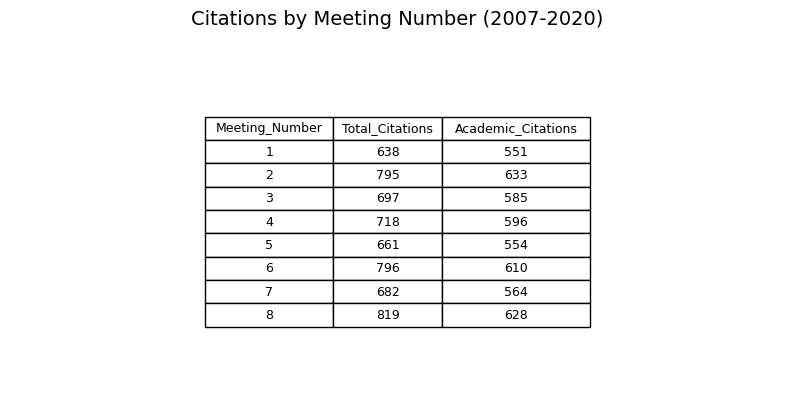

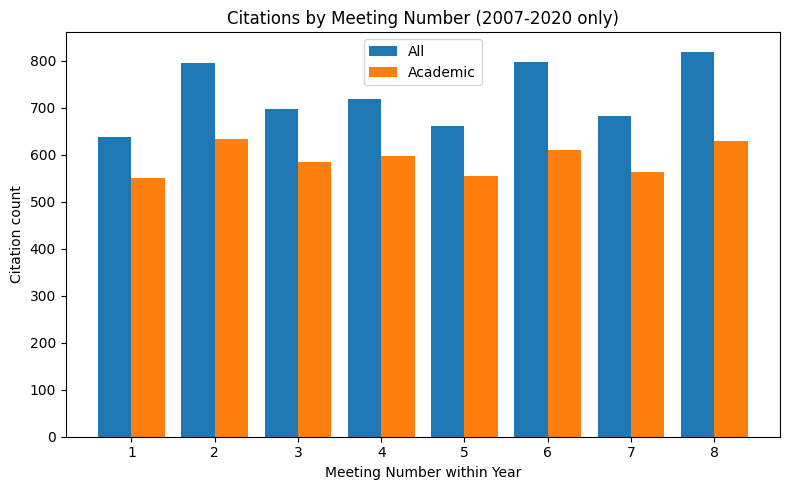

In [13]:
# %% Citations by Meeting Number — truncated to years with all 8 meetings present
#
# Note: this checks which meeting numbers have at least one CITATION recorded
# in a given year, not which meetings actually occurred -- a meeting with zero
# extracted citations would look "missing" here even if it happened. Worth
# spot-checking the FOMC's actual historical meeting calendar if you want to
# be rigorous about this cutoff for the paper.

meetings_per_year = df.groupby("Year")["Meeting_Number"].apply(lambda s: sorted(s.unique()))
full_years = meetings_per_year[meetings_per_year.apply(lambda x: x == list(range(1, 9)))].index
first_full_year = full_years.min()
print(f"First year with all 8 meeting numbers present: {first_full_year}")
print(f"Years included in truncated analysis: {sorted(full_years)}")

df_truncated = df[df["Year"] >= first_full_year].copy()
print(f"\nRows before truncation: {len(df)}, after: {len(df_truncated)}")

# %% Re-run the meeting-number chart on the truncated set
by_meeting_num = (
    df_truncated.groupby("Meeting_Number")
    .agg(Total_Citations=("Citation", "size"), Academic_Citations=("Is_Academic", "sum"))
    .reset_index()
)
print(by_meeting_num)
df_to_pdf_page(by_meeting_num, pdf, title="Citations by Meeting Number (2007-2020)")

fig, ax = plt.subplots(figsize=(8, 5))
x = by_meeting_num["Meeting_Number"]
ax.bar(x - 0.2, by_meeting_num["Total_Citations"], width=0.4, label="All")
ax.bar(x + 0.2, by_meeting_num["Academic_Citations"], width=0.4, label="Academic")
ax.set_xlabel("Meeting Number within Year")
ax.set_ylabel("Citation count")
ax.set_title(f"Citations by Meeting Number ({first_full_year}-{df_truncated['Year'].max()} only)")
ax.legend()
plt.tight_layout()
pdf.savefig()
plt.show()

  Tealbook  Total_Citations  Academic_Citations  Pct_Academic
0        A             2855                2015          70.6
1        B             3015                2762          91.6


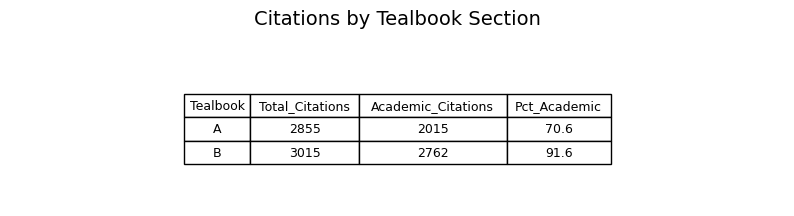

In [14]:
by_tealbook = (
    df.groupby("Tealbook")
    .agg(Total_Citations=("Citation", "size"), Academic_Citations=("Is_Academic", "sum"))
    .reset_index()
)
by_tealbook["Pct_Academic"] = (by_tealbook["Academic_Citations"] / by_tealbook["Total_Citations"] * 100).round(1)
print(by_tealbook)
df_to_pdf_page(by_tealbook, pdf, title="Citations by Tealbook Section")

Tealbook    A    B
Year              
2006        0   56
2007        0  116
2008        0  102
2009        0   94
2010        2   82
2011        4   99
2012       22  340
2013       22  475
2014       40  468
2015       36  425
2016       52  500
2017      497    3
2018      471    0
2019      442    1
2020      427    1


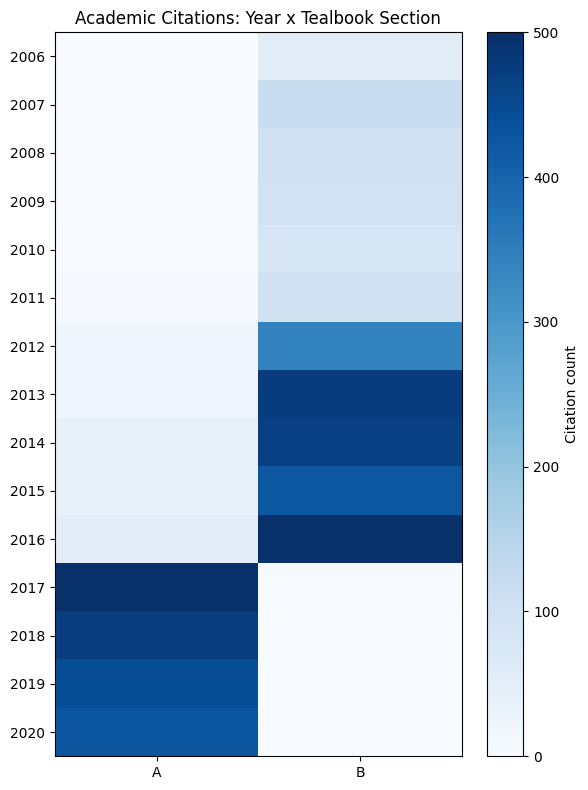

In [15]:
pivot = df[df["Is_Academic"]].pivot_table(
    index="Year", columns="Tealbook", values="Citation", aggfunc="size", fill_value=0
)
print(pivot)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_title("Academic Citations: Year x Tealbook Section")
fig.colorbar(im, ax=ax, label="Citation count")
plt.tight_layout()
pdf.savefig()
plt.show()

Citation
Taylor (1999)                                                                                                                                                                                                                                    2617
Taylor (1993)                                                                                                                                                                                                                                    1511
Orphanides (2003)                                                                                                                                                                                                                                 117
Stanley Lebergott (1957), “Annual Estimates of Unemployment in the United States, 1900–1954,” in National Bureau of Economic Research, The Measurement and Behavior of Unemployment (Princeton, N.J.: Princeton University Press), pp. 213–41      33
Taylor,

/tmp/ipykernel_2631/1322792033.py:31: UserWarning: Glyph 61485 (\uf02d) missing from font(s) DejaVu Sans.
  pdf.savefig()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 61485 (\uf02d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


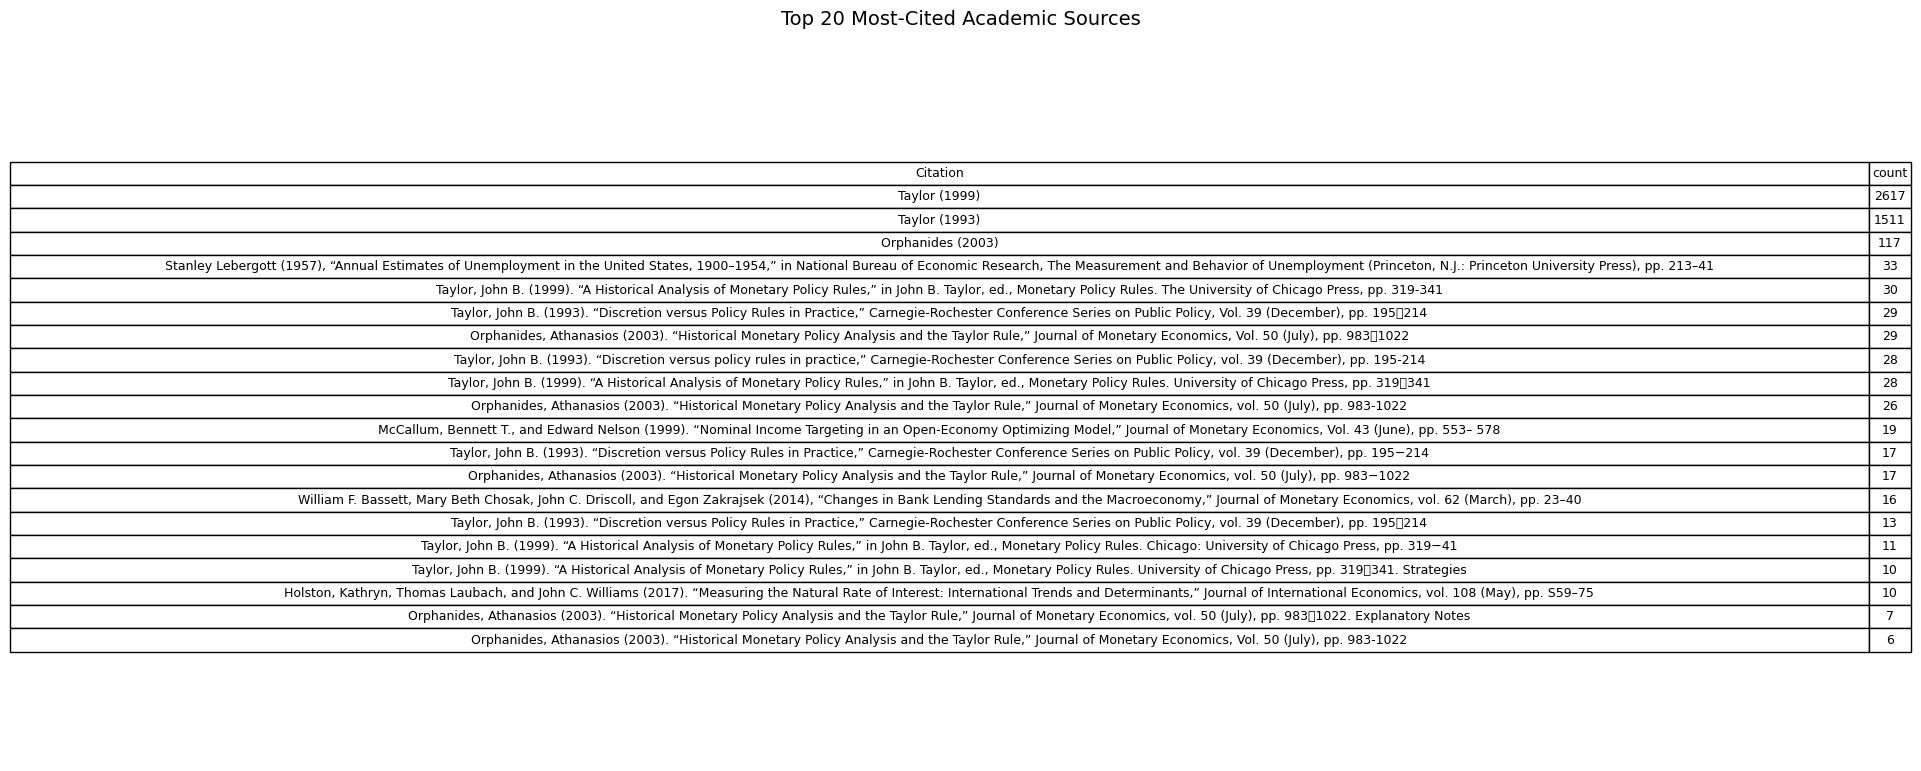

/tmp/ipykernel_2631/3614985100.py:13: UserWarning: Glyph 61485 (\uf02d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2631/3614985100.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2631/3614985100.py:14: UserWarning: Glyph 61485 (\uf02d) missing from font(s) DejaVu Sans.
  pdf.savefig()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 61485 (\uf02d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


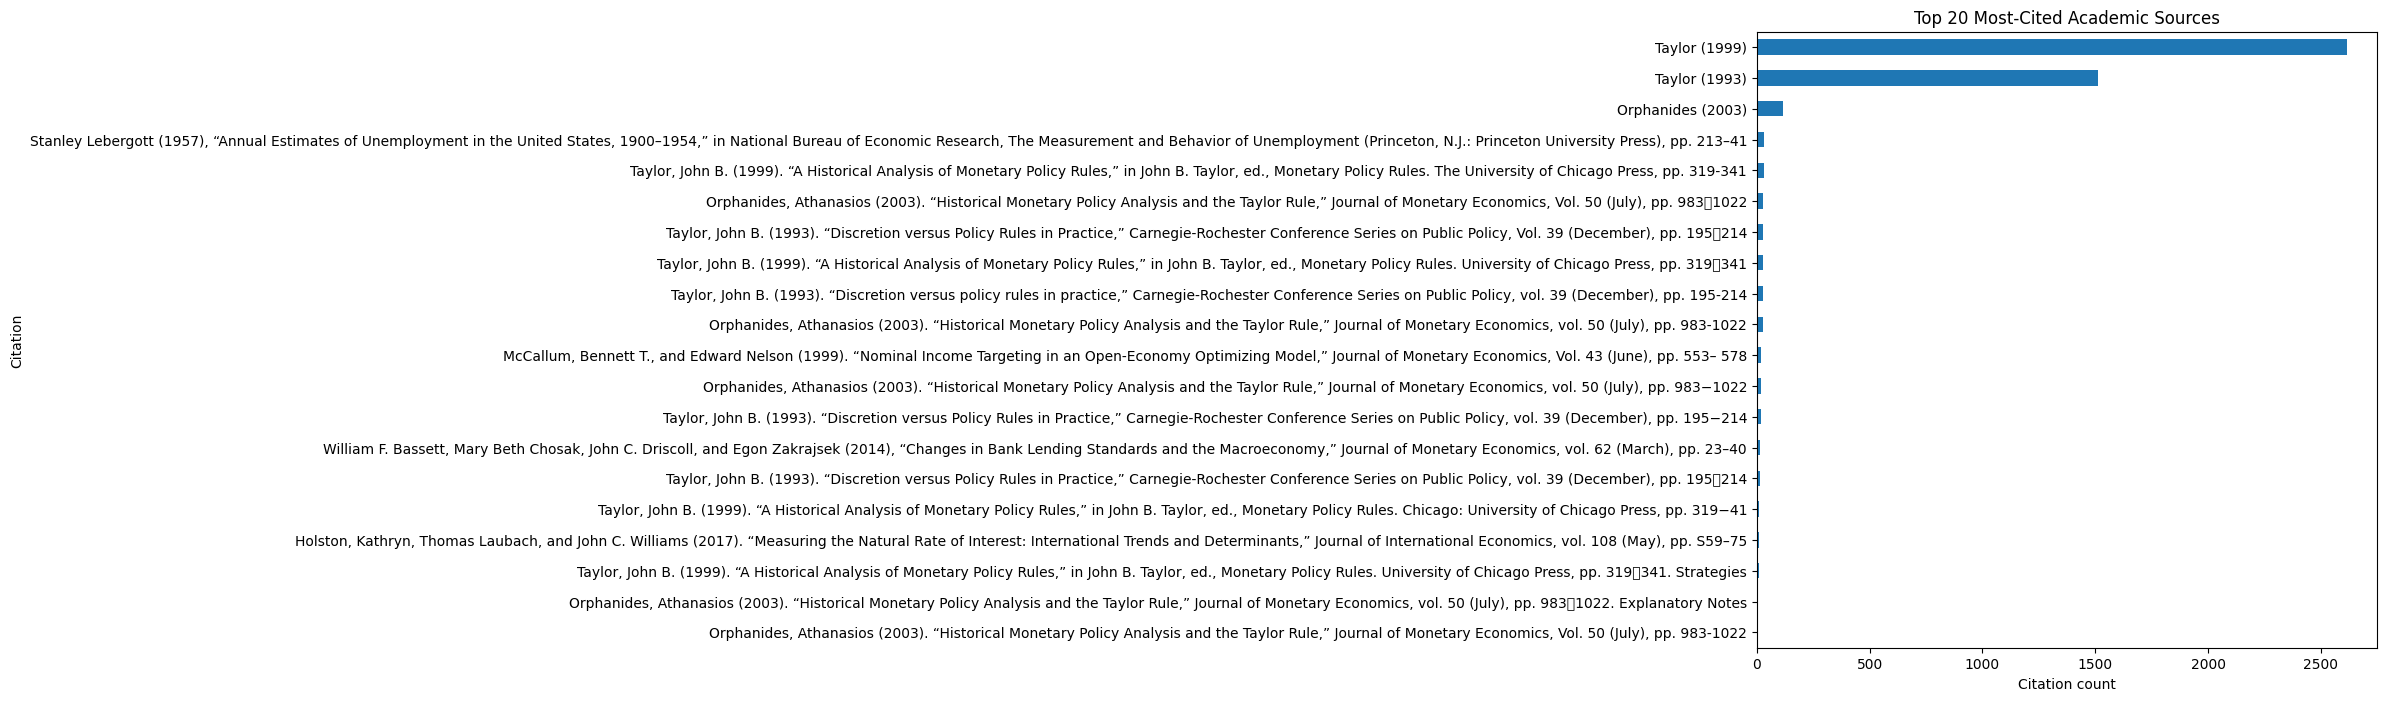

In [16]:
top_academic = (
    df[df["Is_Academic"]]["Citation"]
    .value_counts()
    .head(20)
)
print(top_academic)
df_to_pdf_page(top_academic.reset_index(), pdf, title="Top 20 Most-Cited Academic Sources")

fig, ax = plt.subplots(figsize=(8, 8))
top_academic.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Citation count")
ax.set_title("Top 20 Most-Cited Academic Sources")
plt.tight_layout()
pdf.savefig()
plt.show()

Paper_Type
Book / Chapter     2754
Journal Article    1871
Unknown             124
Working Paper        28
Name: count, dtype: int64


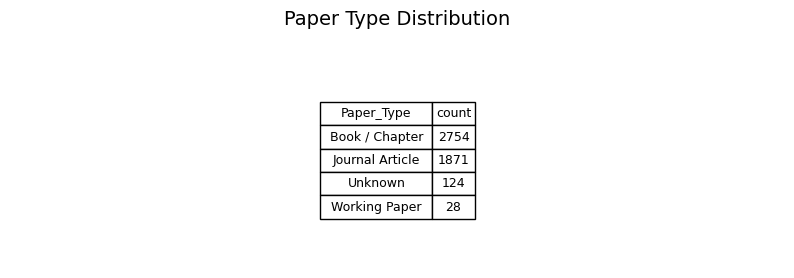

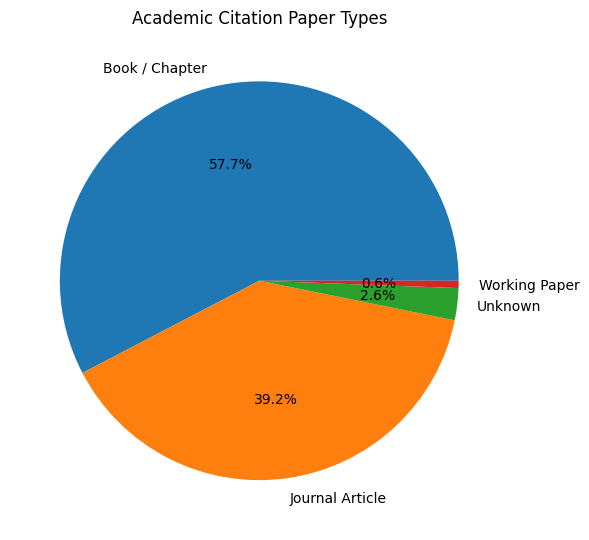

In [17]:
paper_type_counts = df[df["Is_Academic"]]["Paper_Type"].value_counts()
print(paper_type_counts)
df_to_pdf_page(paper_type_counts.reset_index(), pdf, title="Paper Type Distribution")

fig, ax = plt.subplots(figsize=(6, 6))
paper_type_counts.plot(kind="pie", ax=ax, autopct="%1.1f%%")
ax.set_ylabel("")
ax.set_title("Academic Citation Paper Types")
plt.tight_layout()
pdf.savefig()
plt.show()

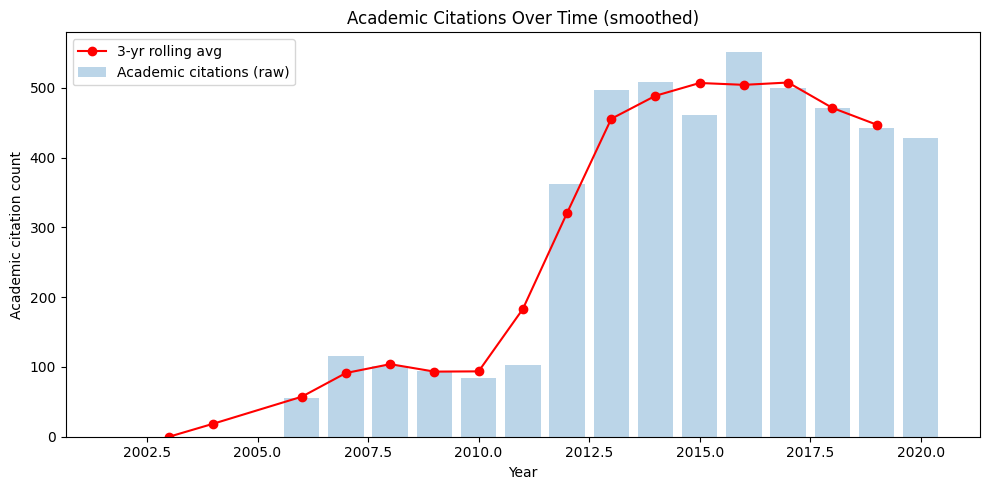

In [18]:
by_year_sorted = by_year.sort_values("Year")
by_year_sorted["Academic_3yr_avg"] = by_year_sorted["Academic_Citations"].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_year_sorted["Year"], by_year_sorted["Academic_Citations"], alpha=0.3, label="Academic citations (raw)")
ax.plot(by_year_sorted["Year"], by_year_sorted["Academic_3yr_avg"], color="red", marker="o", label="3-yr rolling avg")
ax.set_xlabel("Year")
ax.set_ylabel("Academic citation count")
ax.set_title("Academic Citations Over Time (smoothed)")
ax.legend()
plt.tight_layout()
pdf.savefig()
plt.show()

In [19]:
pdf.close()

from google.colab import files
files.download("citation_eda_plots.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>